## Load basic graphs

In [1]:
from networkx.algorithms import bipartite
from copy import deepcopy


In [2]:
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'wikipedia'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/wikipedia/ml_wikipedia.csv


,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2,8229,36.0,0.0,2
2,2,8229,77.0,0.0,3
3,3,8230,131.0,0.0,4
4,2,8229,150.0,0.0,5


In [3]:
# sparsification 
sprs_type = 'ts_tpr_remove_MSS'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
sprs_df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True)
sprs_df.head()

,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2181,8735,429397.0,0.0,20857
2,2198,8735,433126.0,0.0,21023
3,2206,8536,434533.0,0.0,21107
4,2207,8540,434578.0,0.0,21110


In [4]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[2]
early_df = orig_df[(orig_df['ts'] > early_start_time )& (orig_df['ts'] < early_end_time)]
src_nodes_degrees = Counter(early_df['u'])
dst_nodes_degrees = Counter(early_df['i'])

## New tests

In [ ]:
len(sprs_df['u']), len(orig_df['u'])  

def build_graph(graph, is_bipartite=False):
    """
    Build a graph from edge data.
    
    :param graph: DataFrame with columns 'u', 'i', and 'ts' for source, target, and timestamp
    :param is_bipartite: Boolean indicating if the graph should be bipartite
    :return: NetworkX Graph object
    """
    # Extract nodes, edges, and timestamps
    edges = graph[['u', 'i', 'ts']].values
    
    if is_bipartite:
        G = nx.Graph()
        left_set = set()
        right_set = set()
        
        for edge in edges:
            source, target, timestamp = edge
            G.add_edge(source, target, timestamp=timestamp)
            left_set.add(source)
            right_set.add(target)
        
        # Add bipartite attribute to nodes
        nx.set_node_attributes(G, {node: 0 for node in left_set}, 'bipartite')
        nx.set_node_attributes(G, {node: 1 for node in right_set}, 'bipartite')
        
        # Verify bipartiteness
        if not nx.is_bipartite(G):
            raise ValueError("The resulting graph is not bipartite. Check your data.")
    else:
        G = nx.Graph()
        for edge in edges:
            source, target, timestamp = edge
            G.add_edge(source, target, timestamp=timestamp)
    
    return G



# Now we can generate new negative edges from nodes of original graph.
# We only have to take care of bipartite and non-bipartite-ness of graph
# we divide the graph in batches of 10000 consecutive timestamps, we pick nodes of each batch and get their degree sequence of original graph.
# we generate a simple-graph using Havel-hakimi nodes from this batch and degree sequence.
# Using Havel-Hakimi could help generate a set of negative samples (potential adversarial edges) that follow a realistic degree distribution.
# we replenish deficit degree of nodes of this batch by doing a `random` selection of nodes
# we sample timestamp of negatively sampled edges using `TemporalTimeSampler` to maitain C3 constraint
# we satisfy C4 constraint using HH-Algorithm

In [ ]:
def to_int(value):
    """Convert numpy.float64 to int, if possible."""
    if isinstance(value, (np.floating, float)):
        return int(value)
    return value

def generate_negative_samples(original_graph, sparsified_graph, batch_size=10000, is_bipartite=False):
    negative_samples = []
    
    # Sort edges by timestamp
    sorted_edges = sorted(original_graph.edges(data='timestamp'), key=lambda x: x[2])
    
    # Process graph in batches
    for i in range(0, len(sorted_edges), batch_size):
        batch_edges = sorted_edges[i:i+batch_size]
        batch_nodes = set([to_int(u) for u, v, _ in batch_edges] + [to_int(v) for u, v, _ in batch_edges])
        
        if is_bipartite:
            top_nodes = set(to_int(n) for n in batch_nodes if original_graph.nodes[n]['bipartite'] == 0)
            bottom_nodes = batch_nodes - top_nodes
        
        # Get original degree sequence for batch nodes
        original_degrees = {to_int(node): deg for node, deg in original_graph.degree(batch_nodes)}
        sparsified_degrees = {to_int(node): deg for node, deg in sparsified_graph.degree(batch_nodes)}
        
        # Calculate deficit degrees
        deficit_degrees = {to_int(node): degree - sparsified_degrees.get(node, 0) 
                           for node, degree in original_degrees.items()}
        
        # deficit_degrees = {to_int(node): max(0, original_degrees.get(node, 0) - sparsified_degrees.get(node, 0)) 
        #                    for node in batch_nodes}
        
        # Remove nodes with zero deficit degree
        # deficit_degrees = {k: v for k, v in deficit_degrees.items() if v > 0}
        
        if not deficit_degrees:
            continue  # Skip this batch if no deficit degrees
        
        # Ensure the sum of degrees is even
        degree_sum = sum(deficit_degrees.values())
        if degree_sum % 2 != 0:
            node_to_adjust = max(deficit_degrees, key=deficit_degrees.get)
            if deficit_degrees[node_to_adjust] > 1:
                deficit_degrees[node_to_adjust] -= 1
            else:
                deficit_degrees[node_to_adjust] += 1
        
        # Generate a graph using the configuration model
        hh_degree_sequence = list(deficit_degrees.values())
        try:
            hh_graph = nx.havel_hakimi_graph(hh_degree_sequence)
        except Exception as e:
            print(f'Exception {e} raised.')
            hh_graph = nx.configuration_model(hh_degree_sequence)
            hh_graph = nx.Graph(hh_graph)  # Remove parallel edges and self-loops
        
        # Create a mapping from hh_graph nodes to original graph nodes
        node_mapping = dict(zip(hh_graph.nodes(), deficit_degrees.keys()))
        
        # Generate negative samples from the generated graph
        for edge in hh_graph.edges():
            u, v = node_mapping[edge[0]], node_mapping[edge[1]]
            if is_bipartite:
                if (u in top_nodes and v in bottom_nodes) or (v in top_nodes and u in bottom_nodes):
                    negative_samples.append((u, v))
            else:
                negative_samples.append((u, v))
        
        # Calculate remaining deficit
        remaining_deficit = deficit_degrees.copy()
        for edge in hh_graph.edges():
            u, v = node_mapping[edge[0]], node_mapping[edge[1]]
            remaining_deficit[u] = max(0, remaining_deficit[u] - 1)
            remaining_deficit[v] = max(0, remaining_deficit[v] - 1)
        
        # Replenish remaining deficit degrees randomly
        nodes_with_deficit = [node for node, deficit in remaining_deficit.items() if deficit > 0]
        while nodes_with_deficit:
            node = random.choice(nodes_with_deficit)
            if is_bipartite:
                candidate_nodes = bottom_nodes if node in top_nodes else top_nodes
            else:
                candidate_nodes = batch_nodes - {node}
            
            candidate_nodes = [n for n in candidate_nodes if remaining_deficit.get(n, 0) > 0]
            
            if not candidate_nodes:
                nodes_with_deficit.remove(node)
                continue
            
            partner = random.choice(candidate_nodes)
            if not sparsified_graph.has_edge(node, partner) and (node, partner) not in negative_samples:
                negative_samples.append((node, partner))
                remaining_deficit[node] -= 1
                remaining_deficit[partner] -= 1
                
                if remaining_deficit[node] == 0:
                    nodes_with_deficit.remove(node)
                if remaining_deficit[partner] == 0 and partner in nodes_with_deficit:
                    nodes_with_deficit.remove(partner)
    
    return negative_samples

In [ ]:
def generate_negative_samples(original_graph, sparsified_graph, batch_size=10000, is_bipartite=False, src_range=(1, 8227), dst_range=(8228, 9227)):
    negative_samples = []
    
    # Sort edges by timestamp
    sorted_edges = sorted(original_graph.edges(data='timestamp'), key=lambda x: x[2])
    
    # Process graph in batches
    for i in range(0, len(sorted_edges), batch_size):
        batch_edges = sorted_edges[i:i+batch_size]
        batch_nodes = set([to_int(u) for u, v, _ in batch_edges] + [to_int(v) for u, v, _ in batch_edges])
        
        if is_bipartite:
            src_nodes = set(n for n in batch_nodes if src_range[0] <= n <= src_range[1])
            dst_nodes = set(n for n in batch_nodes if dst_range[0] <= n <= dst_range[1])
        else:
            src_nodes = dst_nodes = batch_nodes
        
        # Get original degree sequence for batch nodes
        original_degrees = {to_int(node): deg for node, deg in original_graph.degree(batch_nodes)}
        sparsified_degrees = {to_int(node): deg for node, deg in sparsified_graph.degree(batch_nodes)}
        
        # Calculate deficit degrees
        deficit_degrees = {to_int(node): degree - sparsified_degrees.get(node, 0) 
                           for node, degree in original_degrees.items()}
        
        if not deficit_degrees:
            continue  # Skip this batch if no deficit degrees
        
        # Ensure the sum of degrees is even
        degree_sum = sum(deficit_degrees.values())
        if degree_sum % 2 != 0:
            node_to_adjust = max(deficit_degrees, key=deficit_degrees.get)
            if deficit_degrees[node_to_adjust] > 1:
                deficit_degrees[node_to_adjust] -= 1
            else:
                deficit_degrees[node_to_adjust] += 1
        
        # Generate a graph using the configuration model
        hh_degree_sequence = list(deficit_degrees.values())
        
        try:
            hh_graph = nx.havel_hakimi_graph(hh_degree_sequence)
        except Exception as e:
            print(f'Exception {e} raised.')
            hh_graph = nx.configuration_model(hh_degree_sequence)
            hh_graph = nx.Graph(hh_graph)  # Remove parallel edges and self-loops
        
        # Create a mapping from hh_graph nodes to original graph nodes
        node_mapping = dict(zip(hh_graph.nodes(), deficit_degrees.keys()))
        
        # Generate negative samples from the generated graph
        for edge in hh_graph.edges():
            u, v = node_mapping[edge[0]], node_mapping[edge[1]]
            if is_bipartite:
                if (u in src_nodes and v in dst_nodes) or (v in src_nodes and u in dst_nodes):
                    negative_samples.append((u, v))
            else:
                negative_samples.append((u, v))
        
        # Calculate remaining deficit
        remaining_deficit = deficit_degrees.copy()
        for edge in hh_graph.edges():
            u, v = node_mapping[edge[0]], node_mapping[edge[1]]
            remaining_deficit[u] = max(0, remaining_deficit[u] - 1)
            remaining_deficit[v] = max(0, remaining_deficit[v] - 1)
        
        # Replenish remaining deficit degrees randomly
        nodes_with_deficit = [node for node, deficit in remaining_deficit.items() if deficit > 0]
        while nodes_with_deficit:
            node = random.choice(nodes_with_deficit)
            if is_bipartite:
                candidate_nodes = dst_nodes if node in src_nodes else src_nodes
            else:
                candidate_nodes = batch_nodes - {node}
            
            candidate_nodes = [n for n in candidate_nodes if remaining_deficit.get(n, 0) > 0]
            
            if not candidate_nodes:
                nodes_with_deficit.remove(node)
                continue
            
            partner = random.choice(candidate_nodes)
            if not sparsified_graph.has_edge(node, partner) and (node, partner) not in negative_samples:
                negative_samples.append((node, partner))
                remaining_deficit[node] -= 1
                remaining_deficit[partner] -= 1
                
                if remaining_deficit[node] == 0:
                    nodes_with_deficit.remove(node)
                if remaining_deficit[partner] == 0 and partner in nodes_with_deficit:
                    nodes_with_deficit.remove(partner)
    
    return negative_samples

In [ ]:
original_graph = build_graph(orig_df, is_bipartite=True)
sparsified_graph = build_graph(sprs_df, is_bipartite=True)

# negative_samples = generate_negative_samples(sparsified_graph=sparsified_graph,
#                                              original_graph=original_graph,
#                                              is_bipartite=True,
#                                              src_range=(orig_df['u'].min(), orig_df['u'].max()),
#                                              dst_range=(orig_df['i'].min(), orig_df['i'].max())
#                                              )

In [ ]:
# len(negative_samples), len(original_graph), len(sparsified_graph), len(original_graph) - len(sparsified_graph)

In [ ]:
# orig_df['u'].min(), orig_df['u'].max()  # (1, 8227)
# orig_df['i'].min(), orig_df['i'].max()  # (8228, 9227)

In [ ]:
# ns_df = pd.DataFrame(negative_samples, columns=['u', 'i'])
# ns_df

In [ ]:
# ns_df['u'].min(), ns_df['u'].max()

## Handle bipartite graphs

In [ ]:
negative_samples = []
batch_size = 10000
src_range = (orig_df['u'].min(), orig_df['u'].max())
dst_range = (orig_df['i'].min(), orig_df['i'].max())

# Sort edges by timestamp
sorted_edges = sorted(original_graph.edges(data='timestamp'), key=lambda x: x[2])

In [ ]:
from networkx.algorithms.bipartite import havel_hakimi_graph

def bipartite_havel_hakimi_negative_sampling(original_graph, sparsified_graph, batch_size=10000, src_range=(1, 8227), dst_range=(8228, 9227)):
    negative_samples = []
    
    # Sort edges by timestamp
    sorted_edges = sorted(original_graph.edges(data='timestamp'), key=lambda x: x[2])
    
    print(len(sorted_edges), sorted_edges[:5])
    
    assert 0 == 1, 'break'
    
    # Process graph in batches
    for i in range(0, len(sorted_edges), batch_size):
        batch_edges = sorted_edges[i:i+batch_size]
        print(f'{len(batch_edges) = }', end = ' ')
        batch_src = set(u for u, v, _ in batch_edges if src_range[0] <= u <= src_range[1])
        batch_dst = set(v for u, v, _ in batch_edges if dst_range[0] <= v <= dst_range[1])
        print(f'{len(batch_dst) = } {len(batch_src) = }')
        
        # assert len(batch_dst) == len(batch_src), 'Check1: length of src and dst must be same'
        
        # Get original degree sequence for batch nodes
        original_src_degrees = dict(original_graph.degree(batch_src))
        original_dst_degrees = dict(original_graph.degree(batch_dst))
        
        sparsified_src_degrees = dict(sparsified_graph.degree(batch_src))
        sparsified_dst_degrees = dict(sparsified_graph.degree(batch_dst))
        
        # Calculate deficit degrees
        src_deficit = [max(0, original_src_degrees.get(n, 0) - sparsified_src_degrees.get(n, 0)) for n in batch_src]
        dst_deficit = [max(0, original_dst_degrees.get(n, 0) - sparsified_dst_degrees.get(n, 0)) for n in batch_dst]
        
        # Remove zeros from deficit sequences
        src_deficit = [d for d in src_deficit if d > 0]
        dst_deficit = [d for d in dst_deficit if d > 0]
        
        print(f'{sum(src_deficit) = }, {sum(dst_deficit) = }')
        
        if not src_deficit or not dst_deficit:
            continue  # Skip this batch if no deficit in either partition
        
        try:
            # Generate a bipartite graph using Havel-Hakimi algorithm
            f'generating HH for {i}th batch'
            hh_graph = havel_hakimi_graph(src_deficit, dst_deficit)
            
            # Map the nodes of hh_graph back to original node IDs
            src_nodes = [n for n in batch_src if original_src_degrees.get(n, 0) - sparsified_src_degrees.get(n, 0) > 0]
            dst_nodes = [n for n in batch_dst if original_dst_degrees.get(n, 0) - sparsified_dst_degrees.get(n, 0) > 0]
            
            src_mapping = dict(zip(range(len(src_deficit)), src_nodes))
            dst_mapping = dict(zip(range(len(src_deficit), len(src_deficit) + len(dst_deficit)), dst_nodes))
            
            # Generate negative samples from the Havel-Hakimi graph
            for u, v in hh_graph.edges():
                src = src_mapping[u]
                dst = dst_mapping[v]
                if not sparsified_graph.has_edge(src, dst):
                    negative_samples.append((src, dst))
            
        except nx.NetworkXError as e:
            print(f"\tHavel-Hakimi algorithm failed: {e}")
            print(f"\tFalling back to random sampling for this batch {i}")
            
            # Fall back to random sampling if Havel-Hakimi fails
            src_with_deficit = [n for n in batch_src if original_src_degrees.get(n, 0) > sparsified_src_degrees.get(n, 0)]
            dst_with_deficit = [n for n in batch_dst if original_dst_degrees.get(n, 0) > sparsified_dst_degrees.get(n, 0)]
            
            num_edges = min(sum(src_deficit), sum(dst_deficit))
            for _ in range(num_edges):
                src = random.choice(src_with_deficit)
                dst = random.choice(dst_with_deficit)
                if not sparsified_graph.has_edge(src, dst) and (src, dst) not in negative_samples:
                    negative_samples.append((src, dst))
    
    return negative_samples

In [ ]:
negative_samples = bipartite_havel_hakimi_negative_sampling(original_graph=original_graph,
                                            sparsified_graph=sparsified_graph,
                                            src_range=(orig_df['u'].min(), orig_df['u'].max()),
                                            dst_range=(orig_df['i'].min(), orig_df['i'].max())
                                            )

In [ ]:
from collections import Counter


sum(Counter(orig_df['u']).values()), sum(Counter(orig_df['i']).values())
orig_df.sort_values(by=['ts'])

In [ ]:
def bipartite_havel_hakimi_negative_sampling(original_df, sparsified_df, batch_size=10000, src_range=(1, 8227), dst_range=(8228, 9227)):
    negative_samples = []
    
    # Sort edges by timestamp
    # sorted_edges = sorted(original_graph.edges(data='timestamp'), key=lambda x: x[2])
    sorted_original_df = original_df.sort_values(by=['ts'])
    
    
    # Process graph in batches
    for i in range(0, len(sorted_original_df), batch_size):
        batch_original_df = sorted_original_df[i:i+batch_size]
        batch_sparsified_df = sparsified_df[batch_original_df['ts'].min() < sparsified_df['ts'] < batch_original_df['ts'].max()]
        # print(len(batch_original_df))
        
        batch_src = batch_original_df['u'].unique()
        batch_dst = batch_original_df['i'].unique()
        print(f'{len(batch_dst) = } {len(batch_src) = }')
        
        # assert 0 == 1, 'break'
        
        # build graph
        
        
        # Get original degree sequence for batch nodes
        original_src_degrees = dict(original_graph.degree(batch_src))
        original_dst_degrees = dict(original_graph.degree(batch_dst))
        
        sparsified_src_degrees = dict(sparsified_graph.degree(batch_src))
        sparsified_dst_degrees = dict(sparsified_graph.degree(batch_dst))
        
        # Calculate deficit degrees
        src_deficit = [max(0, original_src_degrees.get(n, 0) - sparsified_src_degrees.get(n, 0)) for n in batch_src]
        dst_deficit = [max(0, original_dst_degrees.get(n, 0) - sparsified_dst_degrees.get(n, 0)) for n in batch_dst]
        
        # Remove zeros from deficit sequences
        src_deficit = [d for d in src_deficit if d > 0]
        dst_deficit = [d for d in dst_deficit if d > 0]
        
        print(f'{sum(src_deficit) = }, {sum(dst_deficit) = }')
        
        if not src_deficit or not dst_deficit:
            continue  # Skip this batch if no deficit in either partition
        
        try:
            # Generate a bipartite graph using Havel-Hakimi algorithm
            f'generating HH for {i}th batch'
            hh_graph = havel_hakimi_graph(src_deficit, dst_deficit)
            
            # Map the nodes of hh_graph back to original node IDs
            src_nodes = [n for n in batch_src if original_src_degrees.get(n, 0) - sparsified_src_degrees.get(n, 0) > 0]
            dst_nodes = [n for n in batch_dst if original_dst_degrees.get(n, 0) - sparsified_dst_degrees.get(n, 0) > 0]
            
            src_mapping = dict(zip(range(len(src_deficit)), src_nodes))
            dst_mapping = dict(zip(range(len(src_deficit), len(src_deficit) + len(dst_deficit)), dst_nodes))
            
            # Generate negative samples from the Havel-Hakimi graph
            for u, v in hh_graph.edges():
                src = src_mapping[u]
                dst = dst_mapping[v]
                if not sparsified_graph.has_edge(src, dst):
                    negative_samples.append((src, dst))
            
        except nx.NetworkXError as e:
            print(f"\tHavel-Hakimi algorithm failed: {e}")
            print(f"\tFalling back to random sampling for this batch {i}")
            
            # Fall back to random sampling if Havel-Hakimi fails
            src_with_deficit = [n for n in batch_src if original_src_degrees.get(n, 0) > sparsified_src_degrees.get(n, 0)]
            dst_with_deficit = [n for n in batch_dst if original_dst_degrees.get(n, 0) > sparsified_dst_degrees.get(n, 0)]
            
            num_edges = min(sum(src_deficit), sum(dst_deficit))
            for _ in range(num_edges):
                src = random.choice(src_with_deficit)
                dst = random.choice(dst_with_deficit)
                if not sparsified_graph.has_edge(src, dst) and (src, dst) not in negative_samples:
                    negative_samples.append((src, dst))
    
    return negative_samples

In [ ]:
negative_samples = bipartite_havel_hakimi_negative_sampling(original_df=orig_df,
                                            sparsified_df=sprs_df,
                                            src_range=(orig_df['u'].min(), orig_df['u'].max()),
                                            dst_range=(orig_df['i'].min(), orig_df['i'].max())
                                            )

In [ ]:
# original_graph, sparsified_graph

# Get original degree sequence for batch nodes
original_src_degrees = dict(original_graph.degree())
original_dst_degrees = dict(original_graph.degree())

sparsified_src_degrees = dict(sparsified_graph.degree())
sparsified_dst_degrees = dict(sparsified_graph.degree())

# Calculate deficit degrees
src_deficit_dict = {n: original_src_degrees.get(n, 0) - sparsified_src_degrees.get(n, 0) for n in original_src_degrees.keys()}
src_deficit = [original_src_degrees.get(n, 0) - sparsified_src_degrees.get(n, 0) for n in original_src_degrees.keys()]

dst_deficit_dict = {n: original_dst_degrees.get(n, 0) - sparsified_dst_degrees.get(n, 0) for n in original_dst_degrees.keys()}
dst_deficit = [original_dst_degrees.get(n, 0) - sparsified_dst_degrees.get(n, 0) for n in original_dst_degrees.keys()]


In [ ]:
# sum(src_deficit), sum(dst_deficit)

hh_graph = havel_hakimi_graph(src_deficit, dst_deficit, create_using=nx.Graph())

In [ ]:
# # Map the nodes of hh_graph back to original node IDs
# src_mapping = dict(zip(range(len(src_deficit)), src_deficit_dict.keys()))
# dst_mapping = dict(zip(range(len(dst_deficit)), dst_deficit_dict.keys()))
# # dst_mapping = dict(zip(range(len(dst_deficit))), dst_deficit_dict.keys())

# # Generate negative samples from the Havel-Hakimi graph
# for u, v in hh_graph.edges():
#     src = src_mapping[u]
#     dst = dst_mapping[v]
#     if not sparsified_graph.has_edge(src, dst):
#         negative_samples.append((src, dst))

In [ ]:
# # Create mappings from Havel-Hakimi graph nodes to original nodes
# src_nodes = [node for node, deficit in src_deficit_dict.items() if deficit > 0]
# dst_nodes = [node for node, deficit in dst_deficit_dict.items() if deficit > 0]

# src_mapping = dict(zip(range(len(src_nodes)), src_nodes))
# dst_mapping = dict(zip(range(len(src_nodes), len(src_nodes) + len(dst_nodes)), dst_nodes))

# # Generate negative samples from the Havel-Hakimi graph
# negative_samples = []
# for u, v in hh_graph.edges():
#     if u < len(src_nodes):  # u is a source node
#         src = src_mapping[u]
#         dst = dst_mapping[v]
#     else:  # u is a destination node, so v must be a source node
#         src = src_mapping[v]
#         dst = dst_mapping[u]
    
#     if not sparsified_graph.has_edge(src, dst):
#         negative_samples.append((src, dst))

# print("Number of negative edge samples:", len(negative_samples))
# print("First few negative edge samples:", negative_samples[:10])

In [ ]:
len(hh_graph.edges()), len(orig_df) - len(sprs_df)

In [ ]:
orig_df['u'].min()

## Some more new test

In [ ]:
orig_df.head()
sprs_df.head()

In [ ]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[2]
early_start_time, early_end_time

In [ ]:
early_df = orig_df[(orig_df['ts'] > early_start_time )& (orig_df['ts'] < early_end_time)]
early_df.head()

In [ ]:
src_nodes_degrees = Counter(early_df['u'])
dst_nodes_degrees = Counter(early_df['i'])

sum(src_nodes_degrees.values()), sum(dst_nodes_degrees.values())


In [ ]:
generated_simple_graphs = nx.bipartite.havel_hakimi_graph(aseq=list(src_nodes_degrees.values()),
                                                          bseq=list(dst_nodes_degrees.values()),
                                                          create_using=nx.Graph())

In [ ]:
# bipartite.is_bipartite(generated_simple_graphs)  # graph is bipartite

edges = generated_simple_graphs.edges()
len(edges)


In [ ]:
# lst_u = [u for u, v in edges]
# lst_v = [v for u, v in edges]

# new_degrees_u, new_degrees_v = Counter(lst_u), Counter(lst_v)

# sum(new_degrees_u), sum(new_degrees_v)

In [ ]:
# sum(dict(generated_simple_graphs.degree()).values())

# top_nodes, bottom_nodes = bipartite.sets(generated_simple_graphs)
# Get the degrees of nodes in both sets
# degrees_top, degrees_bottom = bipartite.degrees(generated_simple_graphs, top_nodes)


# Get the two sets of nodes
top_nodes = set(n for n, d in generated_simple_graphs.nodes(data=True) if d.get('bipartite', 0) == 0)
bottom_nodes = set(generated_simple_graphs) - top_nodes

# Get degrees
degrees_top = {node: generated_simple_graphs.degree(node) for node in top_nodes}
degrees_bottom = {node: generated_simple_graphs.degree(node) for node in bottom_nodes}

In [ ]:
# top_nodes
# bottom_nodes

sum(degrees_top.values()), sum(degrees_bottom.values())

In [ ]:
print(len(top_nodes), len(bottom_nodes))

len(src_nodes_degrees.keys()), len(dst_nodes_degrees.keys())

In [ ]:
src_mapping = {}

for node, degree in src_nodes_degrees.items():
    for top, _degree in degrees_top.items():
        if degree == _degree:
            src_mapping[top] = node

In [ ]:
dst_mapping = {}

for node, degree in dst_nodes_degrees.items():
    for bottom, _degree in degrees_bottom.items():
        if degree == _degree:
            dst_mapping[bottom] = node

In [ ]:
# len(dst_nodes_degrees.items()), len(degrees_bottom.items())

# sum(dst_nodes_degrees.values()), sum(degrees_bottom.values())

# len(dst_mapping)

negative_samples = []
original_edges = early_df[['u', 'i']].values.tolist()

for top, bottom in edges:
    u, v = src_mapping[top], dst_mapping[bottom]
    if (u,v) not in original_edges:
        negative_samples.append((u, v))

len(negative_samples)

In [ ]:
ns_df = pd.DataFrame(negative_samples, columns=['u', 'i'])

len(ns_df['u'].unique()), len(ns_df['i'].unique())

In [ ]:
# len(early_df[['u', 'i']].values.tolist())

# Convert orig_df to a list of tuples
orig_tuples = list(early_df[['u', 'i']].itertuples(index=False, name=None))

In [ ]:
# Check if each tuple in negative_samples exists in orig_tuples
matches = [ns for ns in negative_samples if ns in orig_tuples]

In [ ]:
len(matches)  # we need to generate ns for these again or we can just repeat some edges again??

In [ ]:
matches_df = pd.DataFrame(matches, columns=['u', 'i'])

src_match_df_degree = Counter(matches_df['u'])
dst_match_df_degree = Counter(matches_df['i'])

In [ ]:
sum(src_match_df_degree.values()), sum(dst_match_df_degree.values())

In [ ]:
# should we repeat any edge to make for edges that are not negative samples or should we generate new?

# Prompt: Here is a code for generating negative edges using Havel-Hakimi algorithm. This gets me edges that have same degree sequence as same the original
# graph but few edges are not true negative samples. For these false negative samples should we repeat any edge to make for edges that are not negative samples
# or should we generate new using Havel_hakimi algorithm again?

def swap_edge(edge, negative_samples, original_edges):
    for i, neg_edge in enumerate(negative_samples):
        if edge[0] in neg_edge or edge[1] in neg_edge:
            continue
        if (neg_edge[0], edge[1]) not in original_edges and (edge[0], neg_edge[1]) not in original_edges:
            negative_samples[i] = (neg_edge[0], edge[1])
            return (edge[0], neg_edge[1])
    return None


# Identify false negatives
false_negatives = [edge for edge in negative_samples if edge in orig_tuples]

len(false_negatives)

In [ ]:
for false_neg in false_negatives:
    swapped_edge = swap_edge(false_neg, negative_samples, original_edges)
    if swapped_edge:
        negative_samples[negative_samples.index(false_neg)] = swapped_edge
    else:
        # If swap failed, mark for regeneration
        negative_samples[negative_samples.index(false_neg)] = None

In [ ]:
for ns in negative_samples:
    print(ns)

In [ ]:
ns_df = pd.DataFrame(negative_samples, columns=['u', 'i'])

ns_src_degree = Counter(ns_df['u'])
ns_dst_degree = Counter(ns_df['i'])

In [ ]:
sum(ns_src_degree.values()), sum(ns_dst_degree.values())

In [ ]:
len(ns_src_degree.keys()), len(src_nodes_degrees.keys())

In [ ]:
sorted(ns_src_degree.items(), key=lambda x: x[0])

In [ ]:
len(src_nodes_degrees.keys())

In [ ]:
sum(src_nodes_degrees.values()), sum(ns_src_degree.values())   # same
len(src_nodes_degrees.values()), len(ns_src_degree.values())   # different


In [ ]:
generated_simple_graphs.degree()

In [ ]:
len(dict(generated_simple_graphs.degree()).keys())

In [ ]:
len(src_nodes_degrees.values()), len(dst_nodes_degrees.values()), len(src_nodes_degrees.values()) + len(dst_nodes_degrees.values())

In [ ]:
d = dict(generated_simple_graphs.degree())

n = len(src_nodes_degrees.values())

ns_src_degree = {k: d[k] for k in list(d.keys())[:n]}
ns_dst_degree = {k: d[k] for k in list(d.keys())[n:]}

In [ ]:
len(ns_src_degree), len(ns_dst_degree)

In [ ]:
src_mapping = {}

for node, degree in src_nodes_degrees.items():
    for top, _degree in degrees_top.items():
        if degree == _degree:
            src_mapping[top] = node
            
dst_mapping = {}

for node, degree in dst_nodes_degrees.items():
    for bottom, _degree in degrees_bottom.items():
        if degree == _degree:
            dst_mapping[bottom] = node            


In [ ]:
negative_samples = []
original_edges = early_df[['u', 'i']].values.tolist()

for top, bottom in generated_simple_graphs.edges():
    print(top, bottom, end=' ==> ')
    u, v = src_mapping[top], dst_mapping[bottom]
    print(u, v, end=' ')
    if (u,v) not in original_edges:
        negative_samples.append((u, v))
        print('\t added to ns')

len(negative_samples)

In [ ]:
ns_df = pd.DataFrame(negative_samples, columns=['u', 'i'])

In [ ]:
ns_src_degree_ = Counter(ns_df['u'])
ns_dst_degree_ = Counter(ns_df['i'])

In [ ]:
sorted(ns_src_degree_.items(), key=lambda x: x[0])

In [ ]:
print(len(ns_src_degree_.keys()), len(ns_src_degree.keys()))

sum(ns_src_degree_.values()), sum(ns_src_degree.values())

## test2

In [4]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[2]
early_df = orig_df[(orig_df['ts'] > early_start_time )& (orig_df['ts'] < early_end_time)]
src_nodes_degrees = Counter(early_df['u'])
dst_nodes_degrees = Counter(early_df['i'])

In [5]:
generated_simple_graphs = nx.bipartite.havel_hakimi_graph(aseq=list(src_nodes_degrees.values()),
                                                          bseq=list(dst_nodes_degrees.values()),
                                                          create_using=nx.Graph())
generated_edges = generated_simple_graphs.edges()

len(generated_edges)

21021

In [6]:
d = dict(generated_simple_graphs.degree())

n = len(src_nodes_degrees.values())

degrees_top = {k: d[k] for k in list(d.keys())[:n]}
degrees_bottom = {k: d[k] for k in list(d.keys())[n:]}

sum(degrees_top.values()), sum(degrees_bottom.values()) , sum(src_nodes_degrees.values()), sum(dst_nodes_degrees.values())

(21021, 21021, 21021, 21021)

In [7]:
# src_mapping = {}

# for node, degree in src_nodes_degrees.items():
#     for top, _degree in degrees_top.items():
#         if degree == _degree:
#             src_mapping[top] = node
            
# print(len(src_mapping))

# dst_mapping = {}

# for node, degree in dst_nodes_degrees.items():
#     for bottom, _degree in degrees_bottom.items():
#         if degree == _degree:
#             dst_mapping[bottom] = node
            
# len(dst_mapping)

def create_node_mapping(original_degrees, generated_degrees):
    """Create a one-to-one mapping between generated and original nodes based on degree."""
    # Group original nodes by degree
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    # Group generated nodes by degree
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes[degree]
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

# Usage in the main function:
src_mapping = create_node_mapping(src_nodes_degrees, degrees_top)
dst_mapping = create_node_mapping(dst_nodes_degrees, degrees_bottom)

In [21]:
pd.DataFrame.from_dict(src_mapping, orient='index')

,0
0,2
1,423
421,423
2,4
3,89
...,...
1332,1334
1458,1460
1484,1486
1554,1556


In [26]:
len(set(src_mapping.values())), len(set(src_mapping.keys()))  # 110, 2196 ==> corrected now
len(set(dst_mapping.values())), len(set(dst_mapping.keys()))

(656, 656)

In [28]:
original_edges = early_df[['u', 'i']].values.tolist()
# original_edges

negative_samples = []
cnt = 0
for src, dst in generated_edges:
    # print(src, dst, end=' ==> ')
    u, v = src_mapping[src], dst_mapping[dst]
    # print(u, v)
    edge = (u, v)
    if edge not in original_edges:
        negative_samples.append(edge)
        cnt+=1
len(negative_samples), cnt

(21021, 21021)

In [29]:
ns_df = pd.DataFrame(negative_samples, columns=['u', 'i'])
ns_df.head()

,u,i
0,2,8483
1,2,8495
2,2,8730
3,2,8844
4,2,8369


In [30]:
print(len(ns_df['u'].unique()), len(ns_df['i'].unique()))  # this is a subset of original

ns_src_degree, ns_dst_degree = Counter(ns_df['u']), Counter(ns_df['i'])

2196 656


In [32]:
# sum(ns_src_degree.values())
src_nodes_degrees

Counter({2: 224,
         3: 38,
         4: 152,
         5: 172,
         6: 47,
         7: 28,
         8: 1,
         9: 52,
         10: 10,
         11: 102,
         12: 5,
         13: 113,
         14: 8,
         15: 15,
         16: 3,
         17: 43,
         18: 80,
         19: 47,
         20: 2,
         21: 1,
         22: 2,
         23: 20,
         24: 1,
         25: 30,
         26: 1,
         27: 2,
         28: 164,
         29: 6,
         30: 1,
         31: 3,
         32: 4,
         33: 1,
         34: 2,
         35: 5,
         36: 5,
         37: 57,
         38: 3,
         39: 1,
         40: 40,
         41: 28,
         42: 3,
         43: 10,
         44: 1,
         45: 10,
         46: 5,
         47: 5,
         48: 74,
         49: 33,
         50: 7,
         51: 66,
         52: 32,
         53: 11,
         54: 3,
         55: 5,
         56: 1,
         57: 9,
         58: 6,
         59: 10,
         60: 39,
         61: 9,
         62: 

In [38]:
len(early_df)

21021

## Full Code : Negative sampling gen

In [9]:
import networkx as nx
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Union

def generate_havel_hakimi_graph(degree_sequence: Union[List[int], Tuple[List[int], List[int]]]) -> nx.Graph:
    """
    Generate a graph using the Havel-Hakimi algorithm.
    
    Args:
    degree_sequence: Either a single list of degrees (non-bipartite) or a tuple of two lists (bipartite)
    
    Returns:
    nx.Graph: Generated graph
    """
    if isinstance(degree_sequence, tuple):
        return nx.bipartite.havel_hakimi_graph(degree_sequence[0], degree_sequence[1])
    else:
        return nx.havel_hakimi_graph(degree_sequence)

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

def generate_negative_samples(df: pd.DataFrame, is_bipartite: bool = True) -> List[Tuple[int, int]]:
    """
    Generate negative samples based on the input DataFrame.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination)
    is_bipartite (bool): Whether the graph is bipartite or not
    
    Returns:
    List[Tuple[int, int]]: List of negative samples
    """
    if is_bipartite:
        src_nodes_degrees = Counter(df['u'])
        dst_nodes_degrees = Counter(df['i'])
        degree_sequence = (list(src_nodes_degrees.values()), list(dst_nodes_degrees.values()))
    else:
        all_nodes_degrees = Counter(df['u']) + Counter(df['i'])
        degree_sequence = list(all_nodes_degrees.values())

    generated_graph = generate_havel_hakimi_graph(degree_sequence)
    generated_edges = list(generated_graph.edges())
    
    assert len(df) == len(generated_edges), 'unequal'

    if is_bipartite:
        n = len(src_nodes_degrees)
        degrees = dict(generated_graph.degree())
        degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
        degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
        
        src_mapping = create_node_mapping(src_nodes_degrees, degrees_top)
        dst_mapping = create_node_mapping(dst_nodes_degrees, degrees_bottom)
    else:
        node_mapping = create_node_mapping(all_nodes_degrees, dict(generated_graph.degree()))

    original_edges = set(map(tuple, df[['u', 'i']].values))
    negative_samples = []
    positive_samples = []
    negative_samples_by_source = defaultdict(list)

    for src, dst in generated_edges:
        if is_bipartite:
            u, v = src_mapping[src], dst_mapping[dst]
        else:
            u, v = node_mapping[src], node_mapping[dst]
        
        edge = (u, v)
        if edge not in original_edges and (not is_bipartite or edge[::-1] not in original_edges):
            negative_samples.append(edge)
            negative_samples_by_source[u].append(edge)
        else:
            positive_samples.append(edge)

    # Replace positive samples with repeats of negative samples
    additional_negative_samples = []
    for u, v in positive_samples:
        if negative_samples_by_source[u]:
            # If there are negative samples with the same source, choose one randomly
            replacement = random.choice(negative_samples_by_source[u])
            additional_negative_samples.append(replacement)
        else:
            # If no negative samples with the same source, choose any negative sample
            replacement = random.choice(negative_samples)
            additional_negative_samples.append(replacement)

    # Combine original negative samples with additional ones
    all_negative_samples = negative_samples + additional_negative_samples

    # Sanity checks
    print(f"Original unique edges: {len(original_edges)}")
    print(f"Generated edges: {len(generated_edges)}")
    print(f"Initial negative samples: {len(negative_samples)}")
    print(f"Positive samples replaced: {len(positive_samples)}")
    print(f"Total negative samples: {len(all_negative_samples)}")

    assert len(all_negative_samples) == len(generated_edges), "Mismatch in number of negative samples"

    return all_negative_samples

In [7]:
# For non-bipartite graph
negative_samples_bipartite = generate_negative_samples(early_df, is_bipartite=True)

Original unique edges: 3512
Generated edges: 21021
Initial negative samples: 20794
Positive samples replaced: 227
Total negative samples: 21021


In [15]:
def edge_exists(df, u, v):
    return not df[(df['u'] == u) & (df['i'] == v)].empty

for u, v in negative_samples_bipartite:
    print((u, v), edge_exists(early_df, u, v))

(2, 8483) False
(2, 8495) False
(2, 8730) False
(2, 8844) False
(2, 8369) False
(2, 8370) False
(2, 8380) False
(2, 8437) False
(2, 8582) False
(2, 8620) False
(2, 8831) False
(2, 8855) False
(2, 8471) False
(2, 8621) False
(2, 8643) False
(2, 8700) False
(2, 8273) False
(2, 8287) False
(2, 8391) False
(2, 8292) False
(2, 8466) False
(2, 8469) False
(2, 8788) False
(2, 8449) False
(2, 8659) False
(2, 8758) False
(2, 8856) False
(2, 8274) False
(2, 8367) False
(2, 8447) False
(2, 8550) False
(2, 8590) False
(2, 8430) False
(2, 8450) False
(2, 8543) False
(2, 8264) False
(2, 8306) False
(2, 8320) False
(2, 8439) False
(2, 8448) False
(2, 8463) False
(2, 8518) False
(2, 8409) False
(2, 8570) False
(2, 8602) False
(2, 8834) False
(2, 8282) False
(2, 8393) False
(2, 8467) False
(2, 8778) False
(2, 8876) False
(2, 8351) False
(2, 8376) False
(2, 8442) False
(2, 8528) False
(2, 8577) False
(2, 8230) False
(2, 8446) False
(2, 8662) False
(2, 8832) False
(2, 8247) False
(2, 8384) False
(2, 8452

## Code: Timestamp compliant

In [8]:
import pandas as pd
from collections import Counter, defaultdict
from typing import Set
import random

def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    """
    Get the set of nodes that were active within the time window before current_time.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    current_time (float): Current timestamp
    window (int): Time window size
    
    Returns:
    Set[int]: Set of nodes active within the time window
    """
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

def generate_negative_samples(df: pd.DataFrame, is_bipartite: bool = True, time_window: int = 1200) -> List[Tuple[int, int, float]]:
    """
    Generate negative samples based on the input DataFrame, considering the time window constraint.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    is_bipartite (bool): Whether the graph is bipartite or not
    time_window (int): Time window size for constraint C3
    
    Returns:
    List[Tuple[int, int, float]]: List of negative samples with timestamps
    """
    if is_bipartite:
        src_nodes_degrees = Counter(df['u'])
        dst_nodes_degrees = Counter(df['i'])
        degree_sequence = (list(src_nodes_degrees.values()), list(dst_nodes_degrees.values()))
    else:
        all_nodes_degrees = Counter(df['u']) + Counter(df['i'])
        degree_sequence = list(all_nodes_degrees.values())

    generated_graph = generate_havel_hakimi_graph(degree_sequence)
    generated_edges = list(generated_graph.edges())
    
    assert len(df) == len(generated_edges), 'unequal'

    if is_bipartite:
        n = len(src_nodes_degrees)
        degrees = dict(generated_graph.degree())
        degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
        degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
        
        src_mapping = create_node_mapping(src_nodes_degrees, degrees_top)
        dst_mapping = create_node_mapping(dst_nodes_degrees, degrees_bottom)
    else:
        node_mapping = create_node_mapping(all_nodes_degrees, dict(generated_graph.degree()))

    original_edges = set(map(tuple, df[['u', 'i']].values))
    negative_samples = []
    positive_samples = []
    negative_samples_by_source = defaultdict(list)

    # Sort DataFrame by timestamp
    df_sorted = df.sort_values('ts')
    timestamps = df_sorted['ts'].values

    for idx, (src, dst) in enumerate(generated_edges):
        current_time = timestamps[idx]
        nodes_in_window = get_nodes_in_time_window(df_sorted, current_time, time_window)

        if is_bipartite:
            u, v = src_mapping[src], dst_mapping[dst]
        else:
            u, v = node_mapping[src], node_mapping[dst]
        
        edge = (u, v, current_time)
        
        # Check if the edge satisfies the time window constraint
        if u in nodes_in_window and v in nodes_in_window:
            if (u, v) not in original_edges and (not is_bipartite or (v, u) not in original_edges):
                negative_samples.append(edge)
                negative_samples_by_source[u].append(edge)
            else:
                positive_samples.append(edge)

    # Replace positive samples with repeats of negative samples
    additional_negative_samples = []
    for u, v, t in positive_samples:
        nodes_in_window = get_nodes_in_time_window(df_sorted, t, time_window)
        valid_samples = [s for s in negative_samples_by_source[u] if s[1] in nodes_in_window]
        
        if valid_samples:
            # If there are valid negative samples with the same source, choose one randomly
            replacement = random.choice(valid_samples)
            additional_negative_samples.append(replacement)
        else:
            # If no valid negative samples with the same source, choose any valid negative sample
            valid_samples = [s for s in negative_samples if s[0] in nodes_in_window and s[1] in nodes_in_window]
            if valid_samples:
                replacement = random.choice(valid_samples)
                additional_negative_samples.append(replacement)

    # Combine original negative samples with additional ones
    all_negative_samples = negative_samples + additional_negative_samples

    # Sanity checks
    print(f"Original unique edges: {len(original_edges)}")
    print(f"Generated edges: {len(generated_edges)}")
    print(f"Initial negative samples: {len(negative_samples)}")
    print(f"Positive samples replaced: {len(positive_samples)}")
    print(f"Total negative samples: {len(all_negative_samples)}")

    return all_negative_samples

In [9]:
negative_samples_bipartite = generate_negative_samples(early_df, is_bipartite=True)


Original unique edges: 3512
Generated edges: 21021
Initial negative samples: 96
Positive samples replaced: 10
Total negative samples: 106


## With Temporal Sampler

In [11]:
import networkx as nx
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Union, Set
import random
from scipy import stats
from scipy.spatial import cKDTree

class TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200):
        self.original_graph = original_graph
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.min_time = original_graph['ts'].min()
        self.max_time = original_graph['ts'].max()
        self.initialize_kde()
        self.initialize_kd_tree()

    def initialize_kde(self):
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        self.kde = stats.gaussian_kde(inter_event_times)

    def initialize_kd_tree(self):
        self.temporal_kd_tree = cKDTree(self.original_graph['ts'].values.reshape(-1, 1))

    def assign_timestamps(self, num_samples):
        kde_samples = self.kde.resample(num_samples, self.rng)[0]
        cumulative_times = np.cumsum(kde_samples) + self.min_time
        cumulative_times = np.clip(cumulative_times, self.min_time, self.max_time)
        jitter = self.rng.uniform(0, self.time_window * 0.1, num_samples)
        sampled_timestamps = cumulative_times + jitter
        sampled_timestamps.sort()
        sampled_timestamps = np.clip(sampled_timestamps, self.min_time, self.max_time)
        return sampled_timestamps

    def find_next_events(self, timestamps):
        _, indices = self.temporal_kd_tree.query(timestamps.reshape(-1, 1), k=1)
        return self.original_graph['ts'].values[indices]

def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

def generate_negative_samples(df: pd.DataFrame, is_bipartite: bool = True, time_window: int = 1200) -> List[Tuple[int, int, float]]:
    if is_bipartite:
        src_nodes_degrees = Counter(df['u'])
        dst_nodes_degrees = Counter(df['i'])
        degree_sequence = (list(src_nodes_degrees.values()), list(dst_nodes_degrees.values()))
    else:
        all_nodes_degrees = Counter(df['u']) + Counter(df['i'])
        degree_sequence = list(all_nodes_degrees.values())

    generated_graph = generate_havel_hakimi_graph(degree_sequence)
    generated_edges = list(generated_graph.edges())
    
    # print(len(generated_edges))
    
    if is_bipartite:
        n = len(src_nodes_degrees)
        degrees = dict(generated_graph.degree())
        degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
        degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
        
        src_mapping = create_node_mapping(src_nodes_degrees, degrees_top)
        dst_mapping = create_node_mapping(dst_nodes_degrees, degrees_bottom)
        print(len(src_mapping), len(dst_mapping))
    else:
        node_mapping = create_node_mapping(all_nodes_degrees, dict(generated_graph.degree()))
        
    

    original_edges = set(map(tuple, df[['u', 'i']].values))
    
    # Initialize TemporalSampler
    sampler = TemporalSampler(df, time_window=time_window)
    
    # Generate timestamps for all potential negative samples
    num_samples = len(generated_edges)
    sampled_timestamps = sampler.assign_timestamps(num_samples)
    
    # Shuffle the timestamps
    # np.random.shuffle(sampled_timestamps)
    
    negative_samples = []
    positive_samples = []
    negative_samples_by_source = defaultdict(list)
    df_sorted = df.sort_values('ts')
    
    cnt1=0
    cnt2 = 0
    
    # we can do one thing we can chose one candidate for each timestamp if none is found resample from older ones.

    for idx, ((src, dst), timestamp) in enumerate(zip(generated_edges, sampled_timestamps)):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)

        if is_bipartite:
            u, v = src_mapping[src], dst_mapping[dst]
            # TODO: check if its bipartite
            assert (0<=u<8228) & (8228<=v<9228), "Not following bipartiteness"  # remove for other
        else:
            u, v = node_mapping[src], node_mapping[dst]
            
        cnt1+=1
        
        # This window check is too strict.
        if u in nodes_in_window and v in nodes_in_window:
            if (u, v) not in original_edges and (not is_bipartite or (v, u) not in original_edges):
                negative_samples.append((u, v, sampled_timestamps[idx]))
                cnt2+=1
            else:
                positive_samples.append((u, v, sampled_timestamps[idx]))
        else:
            positive_samples.append((u, v, sampled_timestamps[idx]))
                
    # print(len(negative_samples), cnt1, cnt2)
    
    # Generate additional timestamps for all potential negative samples
    num_samples = len(positive_samples)
    additional_sampled_timestamps = sampler.assign_timestamps(num_samples)
    np.random.shuffle(additional_sampled_timestamps)
    
    additional_negative_samples = []
    
    for idx, (u, v, _) in enumerate(positive_samples):
        if negative_samples_by_source[u]:
            # If there are negative samples with the same source, choose one randomly
            replacement = random.choice(negative_samples_by_source[u])
            u, v, _ = replacement
            additional_negative_samples.append((u, v, additional_sampled_timestamps[idx]))
        else:
            # If no negative samples with the same source, choose any negative sample
            replacement = random.choice(negative_samples)
            u, v, _ = replacement
            additional_negative_samples.append((u, v, additional_sampled_timestamps[idx]))            

    # Combine original negative samples with additional ones
    all_negative_samples = negative_samples + additional_negative_samples

    # Sanity checks
    print(f"Original unique edges: {len(original_edges)}")
    print(f"Generated edges: {len(generated_edges)}")
    print(f"Total negative samples: {len(all_negative_samples)}")

    return all_negative_samples


In [20]:
def fast_filter_edges(edges, src_nodes, dst_nodes):
    # Convert edges and nodes to numpy arrays
    edges_array = np.array(edges)
    src_array = np.array(src_nodes)
    dst_array = np.array(dst_nodes)

    # Create boolean masks
    src_mask = np.isin(edges_array[:, 0], src_array)
    dst_mask = np.isin(edges_array[:, 1], dst_array)

    # Combine masks
    combined_mask = src_mask & dst_mask

    # Apply mask to get filtered edges
    filtered_edges = edges_array[combined_mask]

    return filtered_edges.tolist()

edges = [(1, 4), (2, 5), (3, 6), (1, 5), (2, 4)]
src_nodes = [1, 2, 3]
dst_nodes = [4, 5]

filtered_edges = fast_filter_edges(edges, src_nodes, dst_nodes)
print(filtered_edges)  # Output: [[1, 4], [2, 5], [1, 5], [2, 4]]

[[1, 4], [2, 5], [1, 5], [2, 4]]


In [78]:
def generate_negative_samples(df: pd.DataFrame, is_bipartite: bool = True, time_window: int = 1200, seed:int = 0) -> List[Tuple[int, int, float]]:
    
    # Set the random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    
    if is_bipartite:
        src_nodes_degrees = Counter(df['u'])
        dst_nodes_degrees = Counter(df['i'])
        degree_sequence = (list(src_nodes_degrees.values()), list(dst_nodes_degrees.values()))
    else:
        all_nodes_degrees = Counter(df['u']) + Counter(df['i'])
        degree_sequence = list(all_nodes_degrees.values())

    generated_graph = generate_havel_hakimi_graph(degree_sequence)  # how do we mainitain this?
    generated_edges = list(generated_graph.edges())
    
    # print(len(generated_edges))
    
    if is_bipartite:
        n = len(src_nodes_degrees)
        degrees = dict(generated_graph.degree())
        degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
        degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
        
        src_mapping = create_node_mapping(src_nodes_degrees, degrees_top)
        dst_mapping = create_node_mapping(dst_nodes_degrees, degrees_bottom)
        rev_src_mapping = {value: key for key, value in src_mapping.items()}
        rev_dst_mapping = {value: key for key, value in dst_mapping.items()}
        print(len(src_mapping), len(dst_mapping))
    else:
        node_mapping = create_node_mapping(all_nodes_degrees, dict(generated_graph.degree()))
        rev_node_mapping = {value: key for key, value in node_mapping.items()}
        

    original_edges = set(map(tuple, df[['u', 'i']].values))
    
    # Initialize TemporalSampler
    sampler = TemporalSampler(df, time_window=time_window)
    
    # Generate timestamps for all potential negative samples
    num_samples = len(generated_edges)
    sampled_timestamps = sampler.assign_timestamps(num_samples)
    
    # Shuffle the timestamps
    np.random.shuffle(sampled_timestamps)
    
    negative_samples = []
    positive_samples = []
    negative_samples_by_source = defaultdict(list)
    df_sorted = df.sort_values('ts')
    
    
    # we can do one thing we can chose one candidate for each timestamp if none is found resample from older ones.
    new_generated_edges = deepcopy(generated_edges)  # remove this, is redundant
    already_used = set()
    for timestamp in tqdm(sampled_timestamps, desc='Processing'):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
        
        assert len(nodes_in_window) > 0, f"No nodes in this timestamp {timestamp} for {time_window}. {len(nodes_in_window)}"
        
        if is_bipartite:
            src_nodes_ = [n for n in nodes_in_window if 0 <= n < 8228]  # the numbers will change for each  dataset
            dst_nodes_ = [n for n in nodes_in_window if 8228 <= n < 9228]  # the numbers will change for each  dataset
            
            # we are not using generated graph at all here
            # we need a mapping from original node to generated node
            # we take an edge that contains u from srcnodes and v from dst nodes
            
            src_nodes = [rev_src_mapping[i] for i in src_nodes_]
            dst_nodes = [rev_dst_mapping[i] for i in dst_nodes_]
            
            
            # we take edges that contain any of src_nodes or
            
            edges = [tuple(edge) 
                        for edge in fast_filter_edges(new_generated_edges, src_nodes=src_nodes, dst_nodes=dst_nodes)
                        if edge not in list(already_used)
                    ]
            
            # What if all edges generated in a window has already been used?
            # Then we resample edges from the already_used list based on src and dst nodes 
            
            if len(edges) == 0:
                # we sample from already_used
                print('Updating edge list from already_used set', end='\r')
                edges = [tuple(edge) 
                        for edge in fast_filter_edges(list(already_used), src_nodes=src_nodes, dst_nodes=dst_nodes)
                    ]
                print('Updated edge list from already_used set      ')

            assert len(edges) > 0, "No new edges in this time window."
            
            edge = random.choice(edges)  # this kills the whole C4 argument, then what is the need of havel-hakimi algorithm
            
            already_used.add(edge)
            
            # should I remove this edge from original edges??
            # new_generated_edges = [e for e in new_generated_edges if e!=edge]  # this is for C4. This can't be done.
            
            
            u, v = edge
            
            u, v = src_mapping[u], dst_mapping[v]

        else:
            if len(nodes_in_window) >= 2:
                u, v = random.sample(nodes_in_window, 2)
                u, v = rev_node_mapping[u], rev_node_mapping[v]
                
                # TODO: This is incomplete.
                
            else:
                continue
        
        # =====================================  removing this  made C3 complaint =====================================   
                   
        if (u, v) not in original_edges and (not is_bipartite or (v, u) not in original_edges):
            negative_samples.append((u, v, timestamp))
        else:
            positive_samples.append((u, v, timestamp))
        
        # ==============================================================================================================
        
        # negative_samples.append((u, v, timestamp))
                
    # print(len(negative_samples), cnt)
    
    # Generate additional timestamps for all potential negative samples
    num_samples_to_generate =  len(generated_edges) - len(negative_samples)
    # print(num_samples_to_generate)
    
    # assert 0 == 1, 'break'
    
    additional_sampled_timestamps = sampler.assign_timestamps(num_samples_to_generate)
    np.random.shuffle(additional_sampled_timestamps)
    
    additional_negative_samples = []
    
    for idx, (u, v, _) in enumerate(positive_samples):
        if negative_samples_by_source[u]:
            # If there are negative samples with the same source, choose one randomly
            replacement = random.choice(negative_samples_by_source[u])
            u, v, _ = replacement
            additional_negative_samples.append((u, v, additional_sampled_timestamps[idx]))
        else:
            # If no negative samples with the same source, choose any negative sample
            replacement = random.choice(negative_samples)
            u, v, _ = replacement
            additional_negative_samples.append((u, v, additional_sampled_timestamps[idx]))            

    # Combine original negative samples with additional ones
    all_negative_samples = negative_samples + additional_negative_samples

    # Sanity checks
    print(f"Original unique edges: {len(original_edges)}")
    print(f"Generated edges: {len(generated_edges)}")
    print(f"Total negative samples: {len(all_negative_samples)}")

    return all_negative_samples

In [79]:
negative_samples_bipartite = generate_negative_samples(early_df, is_bipartite=True)

2196 656


Processing: 100%|██████████| 21021/21021 [08:03<00:00, 43.51it/s]

Original unique edges: 3512
Generated edges: 21021
Total negative samples: 21021


In [80]:
ns_df = pd.DataFrame(negative_samples_bipartite, columns=['u', 'i', 'ts']).astype(int)
ns_df.sort_values('ts', inplace=True)
ns_df.reset_index(drop=True, inplace=True)
ns_df.head()

,u,i,ts
0,880,8715,59
1,5,8625,61
2,879,8390,71
3,231,8655,103
4,2,8230,141


In [31]:
orig_df['u'].min(), orig_df['u'].max(), orig_df['i'].min(), orig_df['i'].max()

(1, 8227, 8228, 9227)

In [158]:
len(ns_df)

126

In [146]:
ns_df.groupby(['u'])['ts'].diff()

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
21016     29796.0
21017        83.0
21018      5866.0
21019      2854.0
21020    128223.0
Name: ts, Length: 21021, dtype: float64

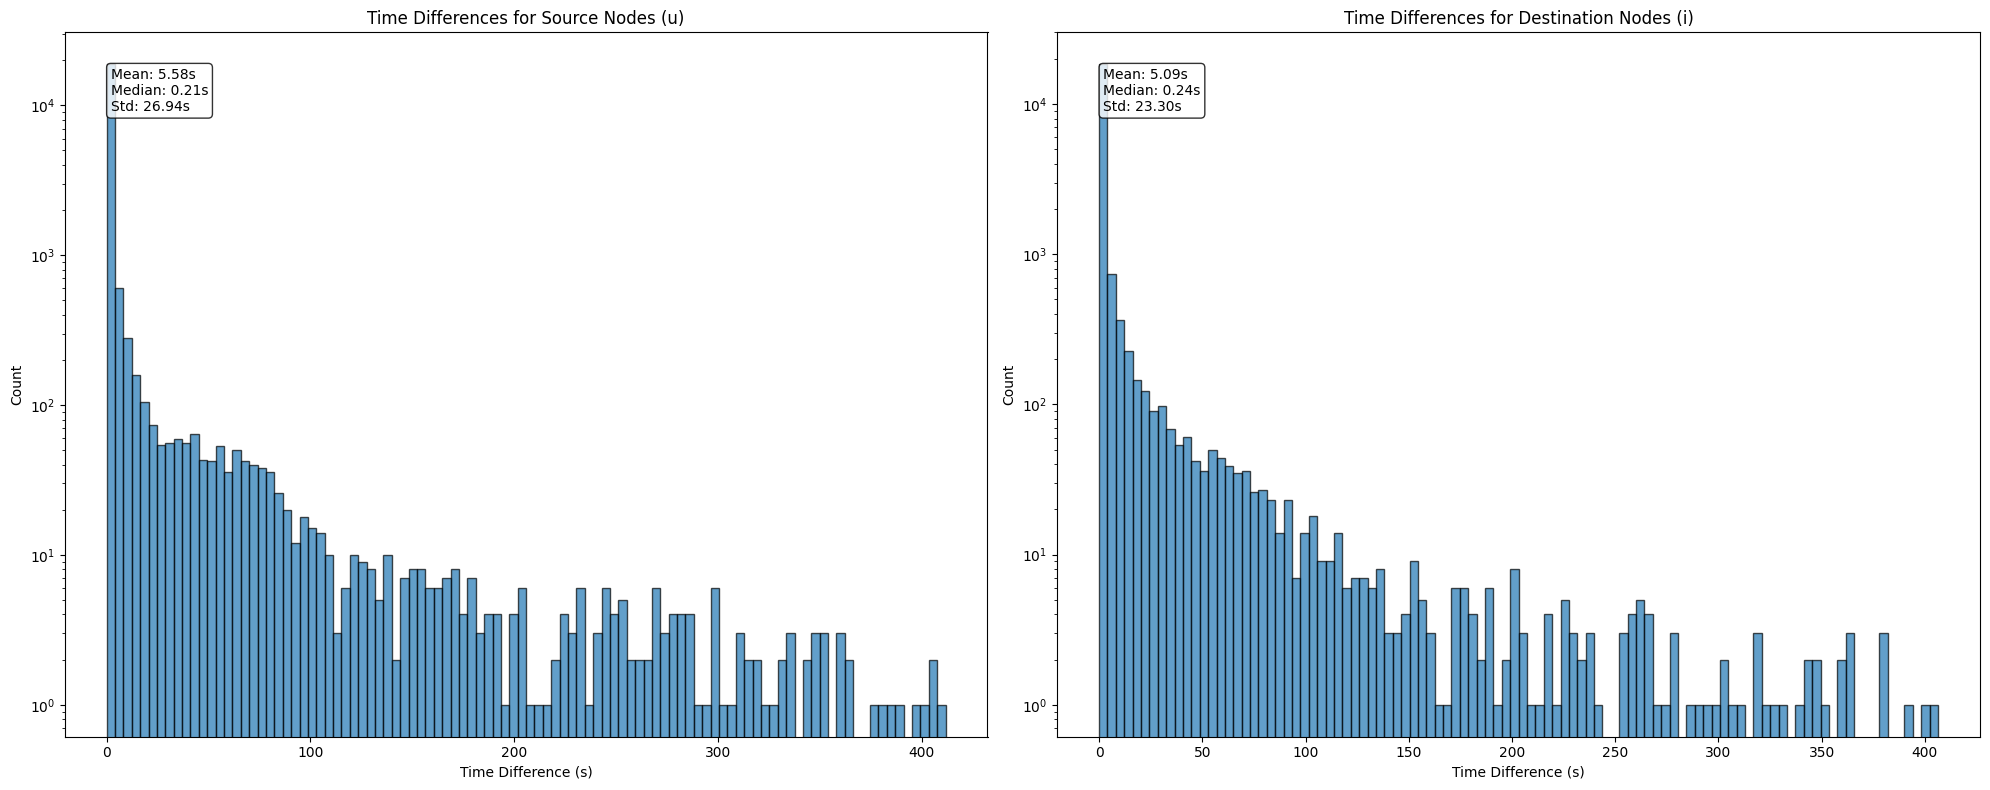

In [81]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [33]:
def check_c3_compliance(df, negative_samples, time_window=1200*1e3):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        window_start = max(ts - time_window, df_sorted['ts'].min())
        window_df = df_sorted[(df_sorted['ts'] >= window_start) & (df_sorted['ts'] <= ts)]
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant

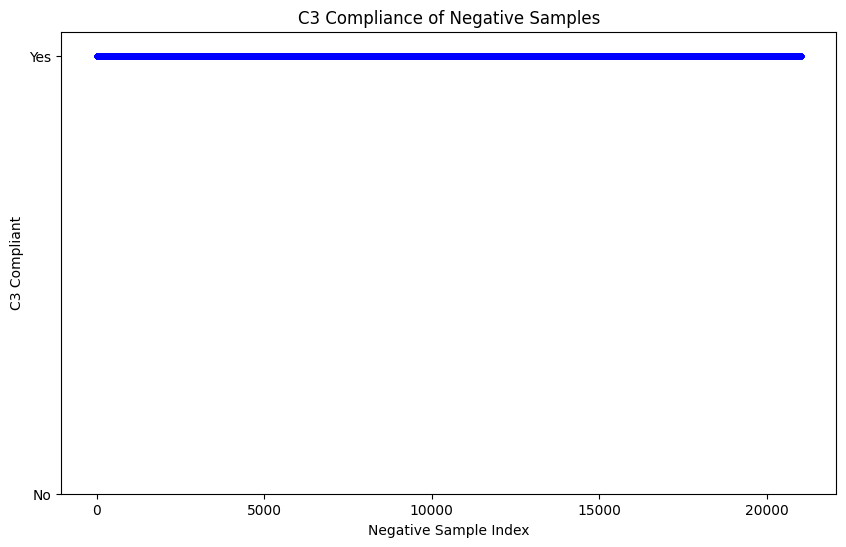

Percentage of C3 compliant samples: 100.00%


In [66]:
compliant = check_c3_compliance(early_df, early_df[['u', 'i', 'ts']].values.tolist())

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title('C3 Compliance of Negative Samples')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

print(f"Percentage of C3 compliant samples: {sum(compliant)/len(compliant)*100:.2f}%")

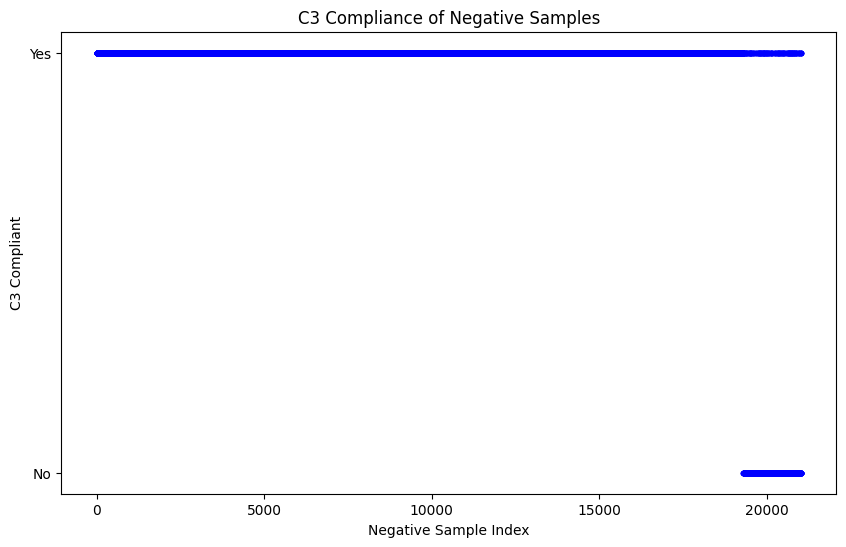

Percentage of C3 compliant samples: 92.75%


In [82]:
compliant = check_c3_compliance(early_df, negative_samples_bipartite)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title('C3 Compliance of Negative Samples')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

print(f"Percentage of C3 compliant samples: {sum(compliant)/len(compliant)*100:.2f}%")

In [75]:
from collections import Counter

def compare_node_degrees(df1, df2, src_col='u', dst_col='i'):
    """
    Compare the degree distributions of source and destination nodes in two DataFrames.
    
    Args:
    df1, df2: pandas DataFrames to compare
    src_col: column name for source nodes (default 'u')
    dst_col: column name for destination nodes (default 'i')
    
    Returns:
    bool: True if both DataFrames have the same degree distributions, False otherwise
    """
    
    # Calculate degree distributions for df1
    src_degrees1 = Counter(df1[src_col])
    src_degrees1 = dict(sorted(src_degrees1.items(), key=lambda x: x[0]))
    dst_degrees1 = Counter(df1[dst_col])
    dst_degrees1 = dict(sorted(dst_degrees1.items(), key=lambda x: x[0]))
    
    # Calculate degree distributions for df2
    src_degrees2 = Counter(df2[src_col])
    src_degrees2 = dict(sorted(src_degrees2.items(), key=lambda x: x[0]))
    dst_degrees2 = Counter(df2[dst_col])
    dst_degrees2 = dict(sorted(dst_degrees2.items(), key=lambda x: x[0]))
    
    print(f"Total source degrees match: {sum(dict(src_degrees1).values()) == sum(dict(src_degrees2).values())}")
    print(f"Total destination degrees match: {sum(dict(dst_degrees1).values()) == sum(dict(dst_degrees2).values())}")
    
    src_keys = list(src_degrees1.keys())
    dst_keys = list(dst_degrees1.keys())
    
    for key in src_keys:
        if src_degrees1[key] != src_degrees2[key]:
            print(f'Degree do not match for {key}: {src_degrees1[key]} {src_degrees2[key]}')
    
    for key in dst_keys:
        if dst_degrees1[key] != dst_degrees2[key]:
            print(f'Degree do not match for {key}: {dst_degrees1[key]} {dst_degrees2[key]}')
    
    # Compare source node degrees
    if src_degrees1 != src_degrees2:
        print("Source node degrees do not match")
        return False
    
    # Compare destination node degrees
    if dst_degrees1 != dst_degrees2:
        print("Destination node degrees do not match")
        return False
    
    print("Both source and destination node degrees match")
    return True

# Usage
compare_node_degrees(early_df, ns_df)

Total source degrees match: True
Total destination degrees match: True
Degree do not match for 2: 224 473
Degree do not match for 3: 38 13
Degree do not match for 4: 152 240
Degree do not match for 5: 172 398
Degree do not match for 6: 47 41
Degree do not match for 7: 28 52
Degree do not match for 9: 52 68


KeyError: 10

In [72]:
# Window-based KDE: Instead of using a single KDE for the entire timeline, create multiple KDEs for different time windows.
# This would allow the sampler to better capture local temporal patterns.

# Timestamp-Node Coupling: When generating timestamps, also keep track of which nodes were active around those times.
# This could be done by creating a temporal index of node activities.


# TODO: check degree C4 constraint too

ns_u_deg = Counter(ns_df['u'])
ns_i_deg = Counter(ns_df['i'])

In [200]:
sorted(ns_u_deg.items(), key=lambda x: x[0])

[(2, 117),
 (3, 12),
 (4, 84),
 (5, 103),
 (6, 53),
 (7, 57),
 (9, 74),
 (10, 19),
 (11, 70),
 (12, 8),
 (13, 114),
 (14, 11),
 (15, 13),
 (16, 10),
 (17, 22),
 (18, 119),
 (19, 63),
 (20, 12),
 (21, 3),
 (22, 5),
 (23, 40),
 (24, 2),
 (25, 54),
 (26, 7),
 (27, 3),
 (28, 169),
 (29, 4),
 (30, 1),
 (31, 4),
 (32, 3),
 (33, 3),
 (34, 4),
 (35, 8),
 (36, 4),
 (37, 87),
 (38, 2),
 (39, 5),
 (40, 52),
 (41, 38),
 (42, 8),
 (43, 14),
 (44, 7),
 (45, 20),
 (46, 14),
 (47, 8),
 (48, 58),
 (49, 17),
 (50, 11),
 (51, 61),
 (52, 13),
 (53, 7),
 (54, 6),
 (55, 4),
 (56, 2),
 (57, 11),
 (58, 15),
 (59, 7),
 (60, 35),
 (61, 17),
 (62, 20),
 (63, 7),
 (64, 31),
 (65, 9),
 (66, 11),
 (67, 40),
 (68, 23),
 (69, 140),
 (70, 8),
 (71, 2),
 (72, 4),
 (73, 16),
 (74, 3),
 (75, 3),
 (76, 35),
 (77, 135),
 (78, 8),
 (79, 27),
 (80, 7),
 (81, 13),
 (82, 25),
 (83, 2),
 (84, 8),
 (85, 13),
 (86, 13),
 (87, 40),
 (88, 6),
 (89, 77),
 (90, 4),
 (91, 16),
 (92, 2),
 (93, 5),
 (94, 12),
 (95, 8),
 (96, 36),
 (97, 

In [201]:
sorted(ns_i_deg.items(), key=lambda x: x[0])

[(8228, 28),
 (8229, 143),
 (8230, 23),
 (8231, 81),
 (8232, 61),
 (8233, 28),
 (8234, 48),
 (8235, 81),
 (8236, 52),
 (8237, 72),
 (8238, 3),
 (8239, 101),
 (8240, 9),
 (8241, 26),
 (8242, 34),
 (8243, 49),
 (8244, 41),
 (8245, 119),
 (8246, 40),
 (8247, 64),
 (8248, 23),
 (8249, 15),
 (8250, 104),
 (8251, 2),
 (8252, 105),
 (8253, 59),
 (8254, 60),
 (8255, 163),
 (8256, 11),
 (8257, 90),
 (8258, 28),
 (8259, 7),
 (8260, 67),
 (8261, 118),
 (8262, 78),
 (8263, 25),
 (8264, 59),
 (8265, 44),
 (8266, 27),
 (8267, 15),
 (8268, 28),
 (8269, 10),
 (8270, 29),
 (8271, 11),
 (8272, 56),
 (8273, 17),
 (8274, 83),
 (8275, 40),
 (8276, 68),
 (8277, 58),
 (8278, 37),
 (8279, 44),
 (8280, 22),
 (8281, 9),
 (8282, 28),
 (8283, 44),
 (8284, 92),
 (8285, 34),
 (8286, 22),
 (8287, 44),
 (8288, 31),
 (8289, 38),
 (8290, 134),
 (8291, 21),
 (8292, 49),
 (8293, 10),
 (8294, 71),
 (8295, 95),
 (8296, 48),
 (8297, 88),
 (8298, 64),
 (8299, 2),
 (8300, 130),
 (8301, 50),
 (8302, 27),
 (8303, 133),
 (8304, 

In [203]:
sum(ns_u_deg.values()), sum(ns_i_deg.values())

(21021, 21021)

## Temporal Aware Havel - Hakimi

In [83]:

class TimestampAwareHavelHakimi:
    def __init__(self, edges, is_bipartite=False, time_window=1200):
        self.edges = edges
        self.is_bipartite = is_bipartite
        self.time_window = time_window
        self.node_timestamps = defaultdict(list)
        self.node_degrees = defaultdict(int)
        self.process_edges()

    def process_edges(self):
        for u, v, t in self.edges:
            self.node_timestamps[u].append(t)
            self.node_timestamps[v].append(t)
            self.node_degrees[u] += 1
            self.node_degrees[v] += 1

    def get_active_nodes(self, current_time):
        active_nodes = set()
        for node, timestamps in self.node_timestamps.items():
            if any(current_time - self.time_window <= t <= current_time for t in timestamps):
                active_nodes.add(node)
        return active_nodes

    def get_degree_sequence(self, nodes):
        return sorted([self.node_degrees[node] for node in nodes], reverse=True)

    def havel_hakimi(self, degree_sequence):
        n = len(degree_sequence)
        adjacency_matrix = np.zeros((n, n), dtype=int)

        for i in range(n - 1):
            d = degree_sequence[i]
            if d == 0:
                break
            for j in range(i + 1, min(i + d + 1, n)):
                adjacency_matrix[i, j] = adjacency_matrix[j, i] = 1
                degree_sequence[j] -= 1
            degree_sequence[i+1:] = sorted(degree_sequence[i+1:], reverse=True)

        return adjacency_matrix

    def generate_negative_samples(self, current_time, num_samples):
        active_nodes = list(self.get_active_nodes(current_time))
        degree_sequence = self.get_degree_sequence(active_nodes)

        if self.is_bipartite:
            # Split active nodes into two sets for bipartite graph
            set_u = [node for node in active_nodes if node in set(edge[0] for edge in self.edges)]
            set_v = [node for node in active_nodes if node in set(edge[1] for edge in self.edges)]
            adj_matrix = np.zeros((len(set_u), len(set_v)), dtype=int)
            
            # Fill adjacency matrix for bipartite graph
            for u, v, _ in self.edges:
                if u in set_u and v in set_v:
                    adj_matrix[set_u.index(u), set_v.index(v)] = 1
        else:
            adj_matrix = self.havel_hakimi(degree_sequence)

        negative_samples = []
        while len(negative_samples) < num_samples:
            if self.is_bipartite:
                i, j = np.random.randint(0, adj_matrix.shape[0]), np.random.randint(0, adj_matrix.shape[1])
                if adj_matrix[i, j] == 0:
                    negative_samples.append((set_u[i], set_v[j], current_time))
            else:
                i, j = np.random.randint(0, adj_matrix.shape[0]), np.random.randint(0, adj_matrix.shape[0])
                if i != j and adj_matrix[i, j] == 0:
                    negative_samples.append((active_nodes[i], active_nodes[j], current_time))

        return negative_samples

In [95]:
# # Example usage
# edges = [(0, 1, 10), (1, 2, 20), (2, 3, 30), (3, 0, 40)]
# hh = TimestampAwareHavelHakimi(edges, is_bipartite=False, time_window=50)
# negative_samples = hh.generate_negative_samples(current_time=45, num_samples=5)
# print("Negative samples:", negative_samples)

In [101]:
import numpy as np
from collections import defaultdict
from bisect import bisect_left

class RobustTimestampAwareHavelHakimi:
    def __init__(self, edges, is_bipartite=False, time_window=1200):
        self.edges = np.array(edges)
        self.is_bipartite = is_bipartite
        self.time_window = time_window
        self.node_timestamps = defaultdict(list)
        self.node_degrees = defaultdict(int)
        self.max_node_id = 0
        self.min_timestamp = np.inf
        self.max_timestamp = -np.inf
        self.process_edges()
        self.adj_matrix = None
        self.active_nodes = None
        self.last_processed_time = None

    def process_edges(self):
        for u, v, t in self.edges:
            self.node_timestamps[u].append(t)
            self.node_timestamps[v].append(t)
            self.node_degrees[u] += 1
            self.node_degrees[v] += 1
            self.max_node_id = max(self.max_node_id, u, v)
            self.min_timestamp = min(self.min_timestamp, t)
            self.max_timestamp = max(self.max_timestamp, t)
        
        for node in self.node_timestamps:
            self.node_timestamps[node].sort()

    def get_active_nodes(self, current_time):
        if self.active_nodes is not None and self.last_processed_time == current_time:
            return self.active_nodes

        active_nodes = set()
        for node, timestamps in self.node_timestamps.items():
            start = bisect_left(timestamps, current_time - self.time_window)
            end = bisect_left(timestamps, current_time + 1)
            if start < end:
                active_nodes.add(node)
        
        self.active_nodes = np.array(list(active_nodes))
        self.last_processed_time = current_time
        return self.active_nodes

    def create_adjacency_matrix(self, current_time):
        active_nodes = self.get_active_nodes(current_time)
        n = len(active_nodes)
        
        if n == 0:
            raise ValueError(f"No active nodes found in the time window [{current_time - self.time_window}, {current_time}]")
        
        if self.is_bipartite:
            set_u = set(self.edges[:, 0])
            set_v = set(self.edges[:, 1])
            nodes_u = np.array([node for node in active_nodes if node in set_u])
            nodes_v = np.array([node for node in active_nodes if node in set_v])
            
            if len(nodes_u) == 0 or len(nodes_v) == 0:
                raise ValueError(f"No valid bipartite split found for active nodes in the time window")
            
            adj_matrix = np.zeros((len(nodes_u), len(nodes_v)), dtype=bool)
            
            edge_mask = np.isin(self.edges[:, 0], nodes_u) & np.isin(self.edges[:, 1], nodes_v)
            edges = self.edges[edge_mask]
            
            u_indices = np.searchsorted(nodes_u, edges[:, 0])
            v_indices = np.searchsorted(nodes_v, edges[:, 1])
            adj_matrix[u_indices, v_indices] = True
        else:
            adj_matrix = np.zeros((n, n), dtype=bool)
            node_to_index = {node: i for i, node in enumerate(active_nodes)}
            
            edge_mask = np.isin(self.edges[:, 0], active_nodes) & np.isin(self.edges[:, 1], active_nodes)
            edges = self.edges[edge_mask]
            
            indices = np.array([(node_to_index[u], node_to_index[v]) for u, v, _ in edges])
            adj_matrix[indices[:, 0], indices[:, 1]] = True
            adj_matrix[indices[:, 1], indices[:, 0]] = True
        
        self.adj_matrix = adj_matrix
        return adj_matrix

    def generate_negative_samples(self, current_time, num_samples):
        if current_time < self.min_timestamp or current_time > self.max_timestamp:
            raise ValueError(f"Current time {current_time} is outside the range of timestamps in the dataset [{self.min_timestamp}, {self.max_timestamp}]")
        
        try:
            adj_matrix = self.create_adjacency_matrix(current_time)
        except ValueError as e:
            print(f"Warning: {str(e)}. Returning empty list of negative samples.")
            return []
        
        if self.is_bipartite:
            i, j = np.where(~adj_matrix)
            if len(i) == 0:
                print(f"Warning: No valid negative samples found for bipartite graph at time {current_time}. Returning empty list.")
                return []
            
            valid_indices = np.random.choice(len(i), size=min(num_samples, len(i)), replace=(len(i) < num_samples))
            negative_samples = np.column_stack((
                self.active_nodes[i[valid_indices]],
                self.active_nodes[j[valid_indices] + adj_matrix.shape[0]],
                np.full(len(valid_indices), current_time)
            ))
        else:
            n = adj_matrix.shape[0]
            i, j = np.triu_indices(n, k=1)
            valid_mask = ~adj_matrix[i, j]
            i, j = i[valid_mask], j[valid_mask]
            
            if len(i) == 0:
                print(f"Warning: No valid negative samples found for non-bipartite graph at time {current_time}. Returning empty list.")
                return []
            
            valid_indices = np.random.choice(len(i), size=min(num_samples, len(i)), replace=(len(i) < num_samples))
            negative_samples = np.column_stack((
                self.active_nodes[i[valid_indices]],
                self.active_nodes[j[valid_indices]],
                np.full(len(valid_indices), current_time)
            ))
        
        return negative_samples

# # Example usage
# edges = [(0, 1, 10), (1, 2, 20), (2, 3, 30), (3, 0, 40)]
# hh = RobustTimestampAwareHavelHakimi(edges, is_bipartite=False, time_window=50)
# negative_samples = hh.generate_negative_samples(current_time=45, num_samples=5)
# print("Negative samples:", negative_samples)

In [106]:
import numpy as np
from collections import defaultdict
from bisect import bisect_left

class BipartiteTimestampAwareHavelHakimi:
    def __init__(self, edges, time_window=1200):
        self.edges = np.array(edges)
        self.time_window = time_window
        self.node_timestamps = defaultdict(list)
        self.node_degrees = defaultdict(int)
        self.min_timestamp = np.inf
        self.max_timestamp = -np.inf
        self.set_u = set()
        self.set_v = set()
        self.process_edges()
        self.adj_matrix = None
        self.active_nodes_u = None
        self.active_nodes_v = None
        self.last_processed_time = None

    def process_edges(self):
        for u, v, t in self.edges:
            self.node_timestamps[u].append(t)
            self.node_timestamps[v].append(t)
            self.node_degrees[u] += 1
            self.node_degrees[v] += 1
            self.set_u.add(u)
            self.set_v.add(v)
            self.min_timestamp = min(self.min_timestamp, t)
            self.max_timestamp = max(self.max_timestamp, t)
        
        for node in self.node_timestamps:
            self.node_timestamps[node].sort()

    def get_active_nodes(self, current_time):
        if self.active_nodes_u is not None and self.active_nodes_v is not None and self.last_processed_time == current_time:
            return self.active_nodes_u, self.active_nodes_v

        active_nodes_u = set()
        active_nodes_v = set()
        for node, timestamps in self.node_timestamps.items():
            start = bisect_left(timestamps, current_time - self.time_window)
            end = bisect_left(timestamps, current_time + 1)
            if start < end:
                if node in self.set_u:
                    active_nodes_u.add(node)
                else:
                    active_nodes_v.add(node)
        
        self.active_nodes_u = np.array(list(active_nodes_u))
        self.active_nodes_v = np.array(list(active_nodes_v))
        self.last_processed_time = current_time
        return self.active_nodes_u, self.active_nodes_v

    def create_adjacency_matrix(self, current_time):
        nodes_u, nodes_v = self.get_active_nodes(current_time)
        
        if len(nodes_u) == 0 or len(nodes_v) == 0:
            raise ValueError(f"No valid bipartite split found for active nodes in the time window")
        
        adj_matrix = np.zeros((len(nodes_u), len(nodes_v)), dtype=bool)
        
        edge_mask = np.isin(self.edges[:, 0], nodes_u) & np.isin(self.edges[:, 1], nodes_v)
        edges = self.edges[edge_mask]
        
        u_indices = np.searchsorted(nodes_u, edges[:, 0])
        v_indices = np.searchsorted(nodes_v, edges[:, 1])
        adj_matrix[u_indices, v_indices] = True
        
        self.adj_matrix = adj_matrix
        return adj_matrix

    def generate_negative_samples(self, current_time, num_samples):
        if current_time < self.min_timestamp or current_time > self.max_timestamp:
            raise ValueError(f"Current time {current_time} is outside the range of timestamps in the dataset [{self.min_timestamp}, {self.max_timestamp}]")
        
        try:
            adj_matrix = self.create_adjacency_matrix(current_time)
        except ValueError as e:
            print(f"Warning: {str(e)}. Returning empty list of negative samples.")
            return []
        
        i, j = np.where(~adj_matrix)
        if len(i) == 0:
            print(f"Warning: No valid negative samples found for bipartite graph at time {current_time}. Returning empty list.")
            return []
        
        valid_indices = np.random.choice(len(i), size=min(num_samples, len(i)), replace=(len(i) < num_samples))
        negative_samples = np.column_stack((
            self.active_nodes_u[i[valid_indices]],
            self.active_nodes_v[j[valid_indices]],
            np.full(len(valid_indices), current_time)
        ))
        
        return negative_samples

In [113]:

original_edges = early_df[['u', 'i', 'ts']].values.tolist()
hh = BipartiteTimestampAwareHavelHakimi(original_edges, time_window=1200)
negative_samples = hh.generate_negative_samples(current_time=100, num_samples=5)
print("Negative samples:", negative_samples)

Negative samples: []


In [122]:

# Define the temporal graph edge structure
class TemporalGraph:
    def __init__(self, bipartite=False):
        self.edges = []  # List of edges (u, v, timestamp)
        self.node_degree = defaultdict(int)  # Degree of each node
        self.adj_list = defaultdict(list)    # Adjacency list with timestamps
        self.bipartite = bipartite
        self.set_U = set()  # Set U for bipartite graphs
        self.set_V = set()  # Set V for bipartite graphs

    def add_edge(self, u, v, t):
        """Add an edge (u, v) with timestamp t"""
        self.edges.append((u, v, t))
        self.node_degree[u] += 1
        self.node_degree[v] += 1
        self.adj_list[u].append((v, t))
        self.adj_list[v].append((u, t))
        if self.bipartite:
            self.set_U.add(u)
            self.set_V.add(v)

    def get_active_nodes(self, current_time, W):
        """Get nodes that were active in the time window [current_time - W, current_time]"""
        active_nodes = set()
        for node, neighbors in self.adj_list.items():
            for _, t in neighbors:
                if current_time - W <= t <= current_time:
                    active_nodes.add(node)
                    break
        return active_nodes

# Time-aware Havel-Hakimi for Negative Sampling
def time_aware_negative_sampling(graph, time_window_W):
    negative_samples = []
    degree_limit = graph.node_degree.copy()  # Track the degree limit for each node
    for (u, v, t) in graph.edges:
        # Get active nodes in the time window [t - W, t]
        active_nodes = graph.get_active_nodes(t, time_window_W)
        
        # Generate negative samples for the edge (u, v)
        if graph.bipartite:
            potential_u_neg = active_nodes.intersection(graph.set_U) - {u}
            potential_v_neg = active_nodes.intersection(graph.set_V) - {v}
        else:
            potential_u_neg = active_nodes - {u}
            potential_v_neg = active_nodes - {v}

        # Use Havel-Hakimi style degree check
        for node in potential_u_neg:
            if degree_limit[u] > 0 and degree_limit[node] > 0:
                negative_samples.append((u, node, t))
                degree_limit[u] -= 1
                degree_limit[node] -= 1

        for node in potential_v_neg:
            if degree_limit[v] > 0 and degree_limit[node] > 0:
                negative_samples.append((v, node, t))
                degree_limit[v] -= 1
                degree_limit[node] -= 1

    return negative_samples

# # Example Usage
# if __name__ == "__main__":
#     # Create a temporal bipartite graph
#     tg = TemporalGraph(bipartite=True)
#     tg.add_edge('u1', 'v1', 10)
#     tg.add_edge('u2', 'v2', 15)
#     tg.add_edge('u1', 'v2', 20)
#     tg.add_edge('u2', 'v1', 25)

#     # Define the time window
#     W = 10

#     # Generate negative samples
#     neg_samples = time_aware_negative_sampling(tg, W)
#     print("Negative samples:")
#     for neg in neg_samples:
#         print(neg)


def time_aware_negative_sampling(graph, time_window_W):
    negative_samples = []
    degree_limit = graph.node_degree.copy()  # Track the degree limit for each node
    for (u, v, t) in graph.edges:
        # Get active nodes in the time window [t - W, t]
        active_nodes = graph.get_active_nodes(t, time_window_W)
        
        if graph.bipartite:
            # Split active nodes into two sets (U and V)
            active_u_set = active_nodes.intersection(graph.set_U) - {u}
            active_v_set = active_nodes.intersection(graph.set_V) - {v}
            
            # Generate negative samples for u from set_U connecting to set_V
            for v_neg in active_v_set:
                if degree_limit[u] > 0 and degree_limit[v_neg] > 0:
                    negative_samples.append((u, v_neg, t))
                    degree_limit[u] -= 1
                    degree_limit[v_neg] -= 1
                    if degree_limit[u] == 0:
                        break  # Stop when degree limit is reached
            
            # Generate negative samples for v from set_V connecting to set_U
            for u_neg in active_u_set:
                if degree_limit[v] > 0 and degree_limit[u_neg] > 0:
                    negative_samples.append((u_neg, v, t))
                    degree_limit[v] -= 1
                    degree_limit[u_neg] -= 1
                    if degree_limit[v] == 0:
                        break  # Stop when degree limit is reached

        else:
            # Non-bipartite case: sample from all active nodes
            potential_u_neg = active_nodes - {u}
            potential_v_neg = active_nodes - {v}

            for node in potential_u_neg:
                if degree_limit[u] > 0 and degree_limit[node] > 0:
                    negative_samples.append((u, node, t))
                    degree_limit[u] -= 1
                    degree_limit[node] -= 1

            for node in potential_v_neg:
                if degree_limit[v] > 0 and degree_limit[node] > 0:
                    negative_samples.append((v, node, t))
                    degree_limit[v] -= 1
                    degree_limit[node] -= 1

    return negative_samples


In [121]:
tg = TemporalGraph(bipartite=True)

for (u, v, t) in original_edges:
    tg.add_edge(u, v, t)
    
len(tg.set_U), len(tg.set_V)

(2196, 656)

In [123]:
# Define the time window
W = 1200

# Generate negative samples
neg_samples = time_aware_negative_sampling(tg, W)

In [118]:
len(neg_samples)
neg_samples[0]

(3.0, 2.0, 131.0)

In [ ]:
ns_df = pd.DataFrame(neg_samples)